# Radar Chart — Multi-Metric Model Comparison
Reuses the master performance table already saved by
`Overall_Performance_Comparison.ipynb` -- no models, no GPU needed. Plots
all 7 models (6 single + proposed ensemble) on one radar chart across
5 metrics (Accuracy, Precision, Recall, F1, AUC) for an at-a-glance
multi-metric comparison.

## Cell 1 — Load the cached performance table

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

output_folder = '/content/drive/MyDrive/thesis_ensemble_outputs'
cache = '/content/drive/MyDrive/thesis_ensemble_outputs/significance_test_cache'

# Rebuild the same master table computed earlier (kept self-contained here
# in case the earlier CSV isn't present) -- reuses cached predictions.
import json as jsonlib
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score

pred_swin = np.load(f'{cache}/pred_swin.npy')
pred_vit = np.load(f'{cache}/pred_vit.npy')
pred_resnet = np.load(f'{cache}/pred_resnet.npy')
pred_densenet = np.load(f'{cache}/pred_densenet.npy')
pred_efficientnet = np.load(f'{cache}/pred_efficientnet.npy')
pred_levit = np.load(f'{cache}/pred_levit.npy')
ensemble_probs = np.load(f'{cache}/ensemble_probs.npy')
true_labels = np.load(f'{cache}/true_labels.npy')

all_models = {
    "Swin": pred_swin, "ViT": pred_vit, "LeViT": pred_levit,
    "ResNet50": pred_resnet, "DenseNet121": pred_densenet,
    "EfficientNetB0": pred_efficientnet, "Proposed Ensemble": ensemble_probs,
}

rows = []
for name, probs in all_models.items():
    pred_labels = np.argmax(probs, axis=1)
    acc = accuracy_score(true_labels, pred_labels)
    prec, rec, f1, _ = precision_recall_fscore_support(true_labels, pred_labels, average='macro', zero_division=0)
    macro_auc = roc_auc_score(true_labels, probs, multi_class='ovr', average='macro')
    rows.append({"Model": name, "Accuracy": acc * 100, "Precision": prec * 100,
                 "Recall": rec * 100, "F1-Score": f1 * 100, "AUC": macro_auc * 100})

master_df = pd.DataFrame(rows)
print(master_df.round(2).to_string(index=False))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
            Model  Accuracy  Precision  Recall  F1-Score   AUC
             Swin     98.42      98.43   98.44     98.43 99.98
              ViT     98.23      98.24   98.20     98.20 99.98
            LeViT     95.15      95.28   95.01     95.13 99.87
         ResNet50     97.95      97.82   97.93     97.87 99.95
      DenseNet121     96.89      96.81   96.72     96.75 99.94
   EfficientNetB0     97.68      97.52   97.58     97.54 99.95
Proposed Ensemble     98.86      98.88   98.87     98.86 99.98


## Cell 2 — Radar chart
All 5 metrics placed on a common 0-100 scale (AUC shown as a percentage).
The radial axis is zoomed to where the data actually lives, so the
differences between models remain visible instead of being compressed.

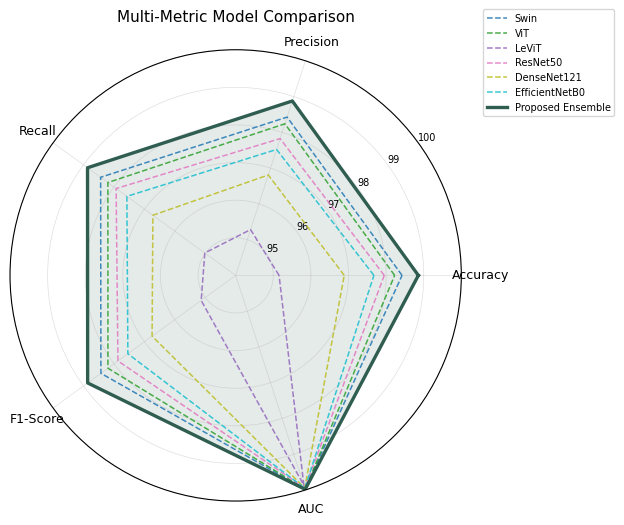

Saved to: /content/drive/MyDrive/thesis_ensemble_outputs/radar_chart_comparison.png


In [3]:
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC"]
n_metrics = len(metrics)

angles = np.linspace(0, 2 * np.pi, n_metrics, endpoint=False).tolist()
angles += angles[:1]   # close the loop

fig, ax = plt.subplots(figsize=(6.5, 6.5), subplot_kw=dict(polar=True))

# radial zoom range -- adjust the lower bound if your models score lower than this
r_min, r_max = 94, 100

colors = plt.cm.tab10(np.linspace(0, 1, len(master_df) - 1))
color_map = {}
ci = 0
for name in master_df["Model"]:
    if name == "Proposed Ensemble":
        color_map[name] = "#2F5D50"
    else:
        color_map[name] = colors[ci]
        ci += 1

for _, row in master_df.iterrows():
    values = [row[m] for m in metrics]
    values += values[:1]
    is_ensemble = row["Model"] == "Proposed Ensemble"
    ax.plot(angles, values, linewidth=2.4 if is_ensemble else 1.1,
            linestyle='-' if is_ensemble else '--',
            color=color_map[row["Model"]], label=row["Model"],
            alpha=1.0 if is_ensemble else 0.85)
    if is_ensemble:
        ax.fill(angles, values, color=color_map[row["Model"]], alpha=0.12)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontsize=9)
ax.set_ylim(r_min, r_max)
ax.set_rlabel_position(180 / n_metrics)
ax.tick_params(axis='y', labelsize=7)
ax.set_title('Multi-Metric Model Comparison', fontsize=11, pad=20)
ax.legend(fontsize=7, loc='upper right', bbox_to_anchor=(1.35, 1.1))
ax.grid(alpha=0.4, linewidth=0.5)

plt.tight_layout()
plt.savefig(f'{output_folder}/radar_chart_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved to: {output_folder}/radar_chart_comparison.png")